Warning message:
“Removed 6 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for Unicode character U+2030”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :


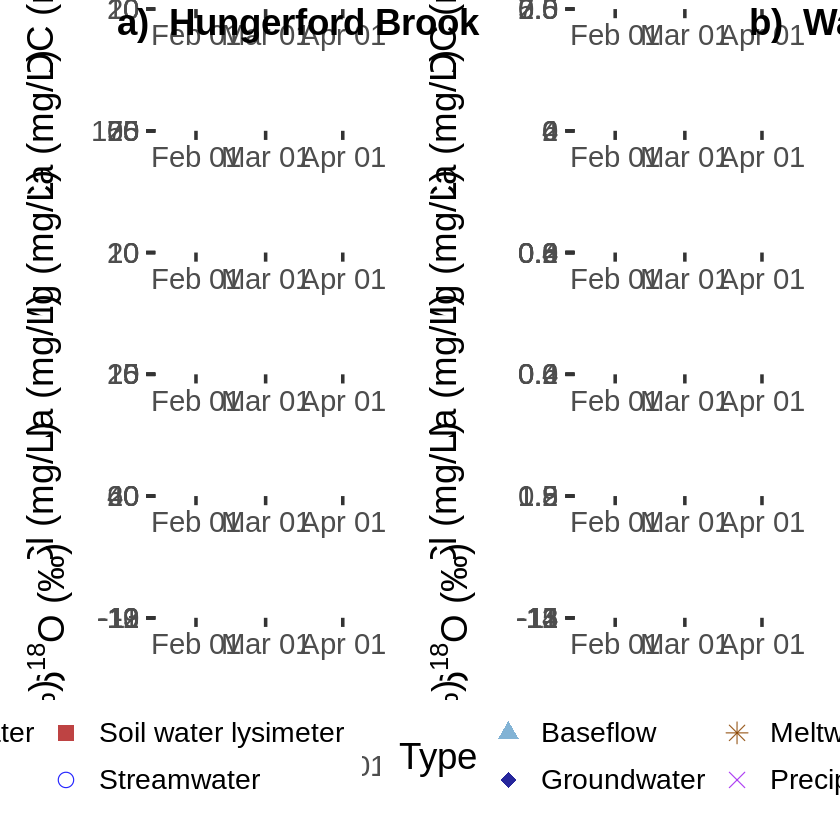

In [6]:
# Import libraries
library(fs)

# Set directories
home_dir <- Sys.getenv("HOME")
repo_dir <- file.path(home_dir, "OneDrive/git-repos/LCBP-interannual-EMMAs")
source(file.path(repo_dir, "Functions/plot_winter_tracer_comparison.R"))
data_dir <- file.path(repo_dir, "Data/")

# 1. Define High-Frequency Sampling Event Windows (Yellow shading) for each site
hungerford_events <- data.frame(
  start = c("2023-02-08 06:00:00", "2023-03-20 12:00:00", "2023-03-30 00:00:00"),
  end   = c("2023-02-12 18:00:00", "2023-03-26 00:00:00", "2023-04-14 12:00:00")
)

wade_events <- data.frame(
  start = c("2023-02-14 06:00:00", "2023-03-20 12:00:00", "2023-03-30 00:00:00"),
  end   = c("2023-02-20 18:00:00", "2023-03-26 00:00:00", "2023-04-11 12:00:00")
)

# 2. Define tracers for each site
hungerford_tracers <- c("DOC_mg_L", "Ca_mg_L", "Mg_mg_L","Na_mg_L", "Cl_mg_L", "d18O", "dD")
wade_tracers       <- c("DOC_mg_L", "Ca_mg_L", "Mg_mg_L","Na_mg_L","Cl_mg_L", "d18O", "dD")

# 3. Call the side-by-side comparison function
comparison_fig <- plot_winter_tracer_comparison(
  site1_name     = "Hungerford",
  site2_name     = "Wade",
  water_year     = 2023,
  event_bounds_1 = hungerford_events,
  event_bounds_2 = wade_events,
  q_file_1       = file.path(data_dir, "StreamSensor_data", "hb_q_chem_20211001-20230930.csv"),
  q_file_2       = file.path(data_dir, "StreamSensor_data", "wb_q_chem_20211001-20230930.csv"),
  chem_data_dir  = file.path(data_dir, "GrabSample_data", "RI23-IC-ICP-isotope-toc-joined.csv"),
  tracer_list_1  = hungerford_tracers,
  tracer_list_2  = wade_tracers,
  q_lim          = c(0, 12),
  base_font_size = 18
)

# 4. View and Save Figure
print(comparison_fig)

ggsave(
  filename = file.path(repo_dir, "Output/Hydrographs/Hungerford_Wade_Winter_2023_comparison.jpg"), 
  plot = comparison_fig, 
  width = 13, 
  height = 16, 
  dpi = 300
)